# Baseline Convergence and Pseudospectra for $1$-Forms

### Magnetic advection–diffusion on the square $\Omega = (0,\pi)^2$, $k = 1$, $n = 2$

---

This notebook establishes the **baseline** against which every later experiment is read: a
convex domain, smooth or vanishing winds, and a spectrum known in closed form. Three
questions are settled here, and nothing else is attempted.

1. **Do the three formulations agree with the analytical Maxwell spectrum?**
   A table of the first five eigenvalues at high resolution, for `A(CG)`, `B(N1)` and
   `B(N2)`.
2. **Are the convergence rates optimal?** $h$-refinement at $p = 1$ and $p = 2$ tracking
   $O(h^{2p})$ for the eigenvalues, $p$-refinement showing spectral convergence, and the
   $L^2$ convergence of the eigen*functions* — reported as tables of computed rates, not
   only as plots.
3. **Do spectrum and pseudospectrum agree for $W^{1,\infty}$ winds?**
   $\varepsilon$-pseudospectra for $\beta_2 = (x,-y)$ and $\beta_4 = (-y,x)$ with the
   computed eigenvalues overlaid, by the partial-Schur-projection method of
   `Lshape_Pseudospectra_Partial_Schur.ipynb`.

Everything is computed for **all three formulations**, so that any one of them can carry
the main text and the other two go to an appendix.

**Contents**

1. [The problem and its exact solution](#1)
2. [Discretisation and solver](#2)
3. [Baseline spectrum, $\beta_0 = 0$](#3)
4. [Convergence](#4)
5. [Pseudospectra for $W^{1,\infty}$ winds](#5)
6. [What is deliberately not here](#6)

<a id="0"></a>
## 0. Setup

In [1]:
from __future__ import annotations

import itertools
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from firedrake import *
from firedrake.function import PointEvaluator
from firedrake.pyplot import triplot, tripcolor

from petsc4py import PETSc
from slepc4py import SLEPc

# The epsilon-pseudospectrum machinery lives in its own module: it works on
# assembled PETSc matrices and knows nothing about the formulation, so the same
# code serves this notebook and the top-form benchmark.
import pseudospectra_partial_schur as ps

# `from firedrake import *` exports a `logging` of its own, so the standard
# library module has to be re-imported under another name afterwards.
import logging as stdlogging
stdlogging.getLogger("firedrake").setLevel(stdlogging.ERROR)
stdlogging.getLogger("tsfc").setLevel(stdlogging.ERROR)

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
L_DOMAIN = np.pi

# PETSc here is built with REAL scalars: SLEPc returns a complex eigenvector as a
# pair (real part, imaginary part) of separate real vectors.
COMPLEX_PETSC = ps.COMPLEX_PETSC

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "figure.dpi": 110, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "axes.linewidth": 0.6,
})

# Publication style for the pseudospectrum panels, matching the L-shape notebook.
PS_RC = {
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02, "ps.fonttype": 42,
}


# --- table rendering, without pandas' jinja2-dependent .style ----------------
def _cell(value, spec):
    if value is None:
        return "--"
    if isinstance(value, complex):
        return (f"{value.real:.5f}{value.imag:+.5f}i" if abs(value.imag) > 1e-10
                else spec.format(value.real))
    try:
        return "--" if not np.isfinite(value) else spec.format(value)
    except (TypeError, ValueError):
        return str(value)


def fmt_table(df, caption=None, default="{:.6f}", rules=(), row_rules=()):
    """Format a DataFrame for display; `rules` match column names, `row_rules`
    index labels and take precedence."""
    def spec_for(key, table):
        name = " ".join(map(str, key)) if isinstance(key, tuple) else str(key)
        # Exact matches win over substring matches: a rule keyed on "m" must not
        # capture a column called "max |Im ritz|".
        return next((spec for k, spec in table if k == name),
                    next((spec for k, spec in table if k in name), None))

    out = pd.DataFrame(
        {col: [_cell(v, spec_for(idx, row_rules) or spec_for(col, rules) or default)
               for idx, v in zip(df.index, df[col])]
         for col in df.columns}, index=df.index)
    if caption:
        display(Markdown(f"**{caption}**"))
    return out


print(f"PETSc scalars: {PETSc.ScalarType.__name__} "
      f"({'complex' if COMPLEX_PETSC else 'real'} build)")

PETSc scalars: float64 (real build)


<a id="1"></a>
## 1. The problem and its exact solution

### 1.1 The operator

The magnetic field $B$ is a **1-form**. With $\varepsilon = R_m^{-1}$ and a prescribed
solenoidal wind $\beta$, the half-Hodge eigenvalue problem
$\varepsilon\,\mathrm{d}^{k-1}\delta^k u + \mathrm{d}^{k-1}\iota^k_\beta u = \lambda u$ at
$k=1$, $n=2$ reads, in vector proxies,

$$
\varepsilon\,\nabla\times\nabla\times B \;+\; \nabla\times(B\times\beta) \;-\; \nabla p \;=\; \lambda B,
\qquad \nabla\!\cdot B = 0,
$$

with the perfectly-conducting boundary condition $B\times n = 0$. In two dimensions
$\nabla\times$ of a vector is the scalar $\operatorname{rot}B = \partial_x B_2-\partial_y B_1$,
and the Lagrange multiplier $p$ enforces the constraint weakly.

Because $\Omega$ is simply connected, $B$ derives from a scalar potential
$B = \nabla\times A = (\partial_y A,\,-\partial_x A)$, which is divergence-free
identically. That gives the equivalent **potential form**

$$
-\varepsilon\,\Delta A \;+\; \beta\cdot\nabla A \;=\; \lambda A,
\qquad \partial_n A = 0 \ \text{ on } \partial\Omega, \qquad \int_\Omega A = 0,
$$

the Neumann condition being the potential-space statement of $B\times n = 0$, and the
zero-mean constraint fixing the gauge. The two carry the same spectrum; that they agree
numerically is the first thing checked below.

### 1.2 The exact baseline spectrum

For $\beta = 0$ and $\varepsilon = 1$ on $\Omega = (0,\pi)^2$ both problems reduce to the
Maxwell/Neumann eigenvalue problem, with

$$
\boxed{\;\lambda_{mn} \;=\; m^2 + n^2, \qquad m, n \ge 0, \quad (m,n)\ne(0,0),\;}
$$

i.e. $1,\,1,\,2,\,4,\,4,\,5,\,5,\,8,\,9,\,9,\dots$, exact to every digit. The corresponding
potentials are $A_{mn} = \cos(mx)\cos(ny)$.

### 1.3 An exact eigen*function* for the convergence study

Eigenvalue convergence can be measured against the table above, but eigenfunction
convergence needs a mode that is **simple** — on a degenerate eigenspace the computed
eigenvector is only determined up to a rotation within the space, and a vector-by-vector
error is meaningless. The value $\lambda = 2$ is the first simple one, arising only from
$(m,n) = (1,1)$:

$$
A \;=\; \cos x\,\cos y,
\qquad
B \;=\; \nabla\times A \;=\; \bigl(-\cos x\,\sin y,\;\; \sin x\,\cos y\bigr),
$$

which indeed satisfies $\operatorname{rot}B = 2A$ and hence
$\nabla\times\nabla\times B = 2B$, with vanishing tangential trace on all four sides. All
three formulations are compared on the same physical quantity $B$ — for `A(CG)` by taking
$\nabla\times A_h$ — so that the numbers mean the same thing across the table.

<a id="2"></a>
## 2. Discretisation and solver

### 2.1 Spaces

The discrete de Rham complex $\mathrm{CG}\xrightarrow{\ \nabla\ }H(\mathrm{curl})$ admits two
simplicial families, and that choice is the only difference between `B(N1)` and `B(N2)`:

$$
\textbf{B(N1)}: \ \ \mathrm{N1curl}_p \times \mathrm{CG}_p ,
\qquad
\textbf{B(N2)}: \ \ \mathrm{N2curl}_p \times \mathrm{CG}_{p+1} ,
\qquad
\textbf{A(CG)}: \ \ \mathrm{CG}_p \ (+\,\mathbb{R}\ \text{gauge}) .
$$

`N1curl` is the trimmed (Nédélec first kind) space, `N2curl` the full (second kind) one;
the scalar partner is one degree higher for `N2curl` so that
$\nabla(\mathrm{CG}_{p+1})\subseteq\mathrm{N2curl}_p$ still holds. For `A(CG)` the gauge
multiplier is attached to the assembled matrix as a rank-one border, because Firedrake
cannot assemble a mixed space containing an `R` block monolithically and the resulting
`MATNEST` is not something MUMPS can factorise.

In [2]:
def crisscross_mesh(N, L=L_DOMAIN):
    r"""Criss-cross (Union-Jack) triangulation of $(0,L)^2$: $4N^2$ cells, $h = L/N$."""
    return SquareMesh(N, N, L, quadrilateral=False, diagonal="crossed")


def cross2d(a, b):
    """Scalar 2D cross product $(a\\times b)_z = a_1b_2 - a_2b_1$; antisymmetric,
    so the ordering in the induction term (`cross2d(v, u)`) is load-bearing."""
    return a[0] * b[1] - a[1] * b[0]


def space(form, mesh, p):
    if form == "A(CG)":
        return FunctionSpace(mesh, "CG", p)
    if form == "B(N1)":
        return FunctionSpace(mesh, "N1curl", p) * FunctionSpace(mesh, "CG", p)
    return FunctionSpace(mesh, "N2curl", p) * FunctionSpace(mesh, "CG", p + 1)


FORMS = ["A(CG)", "B(N1)", "B(N2)"]
STYLE = {"A(CG)": ("C2", "^"), "B(N1)": ("C0", "o"), "B(N2)": ("C1", "s")}

In [3]:
def to_scipy(mat):
    indptr, indices, data = mat.getValuesCSR()
    return sp.csr_matrix((data, indices, indptr), shape=mat.getSize())


def to_petsc(S):
    S = sp.csr_matrix(S); S.sort_indices()
    return PETSc.Mat().createAIJWithArrays(
        S.shape, (S.indptr.astype(PETSc.IntType),
                  S.indices.astype(PETSc.IntType), S.data))


def build_pencil(form, mesh, p=1, beta=None, eps=Constant(1.0)):
    r"""Assemble $(A, M)$ for one formulation. $M$ is singular in every case."""
    if form == "A(CG)":
        V = space(form, mesh, p)
        a_, z = TrialFunction(V), TestFunction(V)
        a = eps * inner(grad(a_), grad(z)) * dx
        if beta is not None:
            a += inner(dot(beta, grad(a_)), z) * dx
        K = assemble(a).petscmat
        M = assemble(inner(a_, z) * dx).petscmat
        # g_i = \int phi_i : the gauge constraint \int A = 0 as a rank-one border,
        #   [[K, -g], [-g^T, 0]] x = lambda [[M, 0], [0, 0]] x.
        g = np.asarray(assemble(TestFunction(V) * dx).dat.data_ro).copy()
        col = sp.csr_matrix(-g.reshape(-1, 1))
        A_b = sp.bmat([[to_scipy(K), col], [col.T, None]], format="csr")
        M_b = sp.bmat([[to_scipy(M), None], [None, sp.csr_matrix((1, 1))]],
                      format="csr")
        return to_petsc(A_b), to_petsc(M_b), V

    W = space(form, mesh, p)
    (v, q) = TrialFunctions(W)
    (w, r) = TestFunctions(W)
    a = eps * inner(curl(v), curl(w)) * dx
    if beta is not None:
        a += inner(cross2d(v, beta), curl(w)) * dx
    a += (-inner(grad(q), w) + inner(v, grad(r))) * dx
    # DirichletBC on an H(curl) space constrains the TANGENTIAL trace, i.e. the
    # perfectly-conducting condition; p = 0 puts the multiplier in CG \cap H^1_0.
    bcs = [DirichletBC(W.sub(0), Constant((0.0, 0.0)), "on_boundary"),
           DirichletBC(W.sub(1), Constant(0.0), "on_boundary")]
    # weight=0.0 gives the constrained rows a zero mass diagonal, so the boundary
    # modes go to lambda = infinity rather than to a spurious lambda = 1.
    return (assemble(a, bcs=bcs).petscmat,
            assemble(inner(v, w) * dx, bcs=bcs, weight=0.0).petscmat, W)

### 2.2 Shift-and-invert, and the conditioning of what is factorised

$M$ is singular in all three formulations — the multiplier block carries no mass — so the
pencil has genuine eigenvalues at infinity and no method that inverts $M$ is admissible.
A reciprocal shift-and-invert transformation replaces $(A,M)$ by
$(A-\tau M)^{-1}M$, whose eigenvalues $\theta = 1/(\lambda-\tau)$ send the infinite ones to
$\theta = 0$, where Krylov–Schur never looks. The shifted matrix is an indefinite
saddle-point system, so it is factorised directly with MUMPS.

That makes $\kappa(A - \tau M)$ the number certifying the whole computation, and it is
reported with **every** result below: `solve_eigs` estimates it on each call and attaches
it to the result. Two estimators are used, as in the top-form benchmark — the normwise
Hager–Higham $\kappa_1$ (sparse LU plus a one-norm power iteration) and MUMPS' own
`COND1` from `ICNTL(11)=1`, read out of `RINFOG(10)`.

In [4]:
EPS_OPTS = {
    "eps_gen_non_hermitian": None,
    "eps_type": "krylovschur",
    "eps_target_magnitude": None,
    "eps_tol": 1e-12,
    "eps_max_it": 5000,
    "st_type": "sinvert",
    "st_ksp_type": "preonly",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 800,
}
_prefix = itertools.count()
KAPPA_LOG = []


def shifted_matrix(A, M, sigma):
    S = A.copy()
    S.axpy(-sigma, M, structure=PETSc.Mat.Structure.DIFFERENT_NONZERO_PATTERN)
    return S


def condition_estimates(A, M, sigma):
    r"""Estimates of $\kappa(A-\sigma M)$: normwise $\kappa_1$, and MUMPS' COND1."""
    S = shifted_matrix(A, M, sigma)

    ksp = PETSc.KSP().create(comm=S.getComm())
    ksp.setOperators(S); ksp.setType("preonly")
    pc = ksp.getPC(); pc.setType("lu"); pc.setFactorSolverType("mumps")
    # The factor Mat has to exist before the numeric factorisation for ICNTL(11)
    # to take effect; the error analysis itself runs during the solve.
    pc.setFactorSetUpSolverType()
    F = pc.getFactorMatrix()
    F.setMumpsIcntl(11, 1)
    F.setMumpsIcntl(14, 800)
    ksp.setUp()
    b, xv = S.createVecLeft(), S.createVecRight()
    b.set(1.0)
    ksp.solve(b, xv)
    cond1, infog1 = F.getMumpsRinfog(10), F.getMumpsInfog(1)
    ksp.destroy()

    Ssp = to_scipy(S).tocsc()
    lu = spla.splu(Ssp)
    n = Ssp.shape[0]
    inverse = spla.LinearOperator(
        (n, n), matvec=lu.solve, rmatvec=lambda v: lu.solve(v, trans="T"))
    kappa1 = spla.onenormest(Ssp) * spla.onenormest(inverse)
    return {r"Hager $\kappa_1$": kappa1, "MUMPS COND1": cond1, "INFOG(1)": infog1}


@dataclass
class Result:
    values: np.ndarray
    index: np.ndarray
    solver: object
    A: object
    space: object
    form: str
    ndof: int
    kappa: dict

    @property
    def real(self):
        return self.values.real

    @property
    def kappa1(self):
        return self.kappa[r"Hager $\kappa_1$"]


#: Eigenvalues above this are the multiplier block's modes at infinity, returned
#: as large finite numbers by an ill-conditioned coarse pencil.  The resolved
#: spectrum here is O(10^2), so the gap is wide and the threshold uncritical.
INF_TOL = 1e6


def solve_eigs(form, mesh, p=1, beta=None, Rm=1.0, tau=None, nev=25, cond=True):
    r"""Shift-and-invert solve for one configuration, with $\kappa(A-\tau M)$ attached.

    `tau` defaults to $0.9\varepsilon$, just below the first Maxwell eigenvalue
    $\lambda_1 = \varepsilon$; that keeps the wanted end of the spectrum nearest
    the shift without ever sitting on it.
    """
    eps = Constant(1.0 / Rm)
    tau = 0.9 / Rm if tau is None else tau
    A, M, W = build_pencil(form, mesh, p, beta=beta, eps=eps)

    opts = dict(EPS_OPTS, eps_target=tau,
                eps_ncv=min(2 * nev + 30, A.getSize()[0]))
    prefix = f"bl{next(_prefix)}_"
    db = PETSc.Options()
    for k, v in opts.items():
        db[prefix + k] = v
    solver = SLEPc.EPS().create(comm=A.getComm())
    solver.setOptionsPrefix(prefix)
    solver.setOperators(A, M)
    solver.setDimensions(nev=nev)
    solver.setFromOptions()
    solver.solve()
    for k in opts:
        db.delValue(prefix + k)

    found = []
    for i in range(solver.getConverged()):
        z = complex(solver.getEigenvalue(i))
        if np.isfinite(z) and 1e-9 < abs(z) < INF_TOL:
            found.append((i, z))
    found.sort(key=lambda t: (t[1].real, abs(t[1].imag)))

    kappa = condition_estimates(A, M, tau) if cond else None
    if kappa is not None:
        KAPPA_LOG.append(dict(form=form, p=p, N=mesh.num_cells(), Rm=Rm,
                              tau=tau, **kappa))
    return Result(np.array([z for _, z in found]),
                  np.array([i for i, _ in found]), solver, A, W, form,
                  A.getSize()[0], kappa)


def eigenfunction(res, k):
    """The k-th eigenmode: the H(curl) field for B(...), the potential for A(CG)."""
    vr, vi = res.A.createVecRight(), res.A.createVecRight()
    res.solver.getEigenvector(int(res.index[k]), vr, vi)
    arr = np.asarray(vr.getArray())
    if res.form == "A(CG)":
        f = Function(res.space)
        f.dat.data[:] = arr[:res.space.dim()]
        return f
    f = Function(res.space)
    with f.dat.vec_wo as fv:
        fv.setArray(arr[:fv.getLocalSize()])
    return f.subfunctions[0]


def exact_spectrum(n, Rm=1.0, kmax=30):
    r"""$\varepsilon(m^2+n^2)$, $m,n\ge0$, $(m,n)\ne(0,0)$, with multiplicity."""
    vals = sorted(m * m + k * k for m in range(kmax) for k in range(kmax)
                  if (m, k) != (0, 0))
    return np.array(vals[:n], dtype=float) / Rm


#: The exact eigenvalue *clusters* covering the first five eigenvalues, each with
#: the index pairs $(m,n)$ whose potential $\cos(mx)\cos(ny)$ spans its eigenspace.
#: Clusters rather than individual modes because $\lambda = 1$ and $\lambda = 4$
#: are double: on a degenerate eigenspace the computed eigenvector is only defined
#: up to a rotation within the space, so a vector-by-vector error is meaningless.
CLUSTERS = [(1.0, [(1, 0), (0, 1)]),
            (2.0, [(1, 1)]),
            (4.0, [(2, 0), (0, 2)])]
N_TRACK = 5          # eigenvalues followed individually in the convergence study


def exact_field(mesh, m, n):
    r"""$B = \nabla\times\cos(mx)\cos(ny) = (-n\cos mx\,\sin ny,\ m\sin mx\,\cos ny)$."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([-n * cos(m * x) * sin(n * y),
                      m * sin(m * x) * cos(n * y)])

<a id="3"></a>
## 3. Baseline spectrum, $\beta_0 = 0$

The first five eigenvalues at $p = 1$ on a fine criss-cross mesh. With no wind the operator
is self-adjoint, so the computed spectrum must be real, and it must reproduce
$\{1, 1, 2, 4, 4\}$.

In [5]:
N_FINE, P_BASE = 64, 1
mesh_fine = crisscross_mesh(N_FINE)

runs0 = {f: solve_eigs(f, mesh_fine, p=P_BASE, nev=25) for f in FORMS}

ex5 = exact_spectrum(5)
tbl = pd.DataFrame({"exact": ex5} | {f: runs0[f].real[:5] for f in FORMS},
                   index=[rf"$\lambda_{{{i+1}}}$" for i in range(5)])
for f in FORMS:
    tbl[f"rel err {f}"] = np.abs(tbl[f] - ex5) / ex5
# Conditioning of the matrix each column was produced from, and the size of it.
tbl.loc[r"$\kappa_1(A-\tau M)$"] = [np.nan] + [runs0[f].kappa1 for f in FORMS] + [np.nan] * 3
tbl.loc["pencil size"] = [np.nan] + [runs0[f].ndof for f in FORMS] + [np.nan] * 3

fmt_table(tbl, rules=[("rel err", "{:.2e}")],
          row_rules=[(r"\kappa_1", "{:.2e}"), ("pencil", "{:.0f}")],
          caption=rf"First five eigenvalues, $\beta_0 = 0$, $p = {P_BASE}$, criss-cross "
                  rf"$N = {N_FINE}$ ($h = \pi/{N_FINE}$, {mesh_fine.num_cells()} cells)")

**First five eigenvalues, $\beta_0 = 0$, $p = 1$, criss-cross $N = 64$ ($h = \pi/64$, 16384 cells)**

,exact,A(CG),B(N1),B(N2),rel err A(CG),rel err B(N1),rel err B(N2)
$\lambda_{1}$,1.000000,1.000134,1.000017,1.000067,1.34e-04,1.67e-05,6.69e-05
$\lambda_{2}$,1.000000,1.000134,1.000017,1.000067,1.34e-04,1.67e-05,6.69e-05
$\lambda_{3}$,2.000000,2.000335,1.999866,2.000268,1.67e-04,6.69e-05,1.34e-04
$\lambda_{4}$,4.000000,4.002142,4.000268,4.001071,5.36e-04,6.69e-05,2.68e-04
$\lambda_{5}$,4.000000,4.002142,4.000268,4.001071,5.36e-04,6.69e-05,2.68e-04
$\kappa_1(A-\tau M)$,--,1.35e+05,1.23e+07,4.49e+07,--,--,--
pencil size,--,8322,33025,82433,--,--,--


In [6]:
print("self-adjointness check (u = 0 must give a real spectrum):")
for f in FORMS:
    v = runs0[f].values[:20]
    print(f"  {f:7s} max |Im lambda| = {np.abs(v.imag).max():.3e}"
          f"    MUMPS COND1 = {runs0[f].kappa['MUMPS COND1']:.2e}"
          f"    INFOG(1) = {runs0[f].kappa['INFOG(1)']}")

self-adjointness check (u = 0 must give a real spectrum):
  A(CG)   max |Im lambda| = 0.000e+00    MUMPS COND1 = 4.72e+02    INFOG(1) = 0
  B(N1)   max |Im lambda| = 0.000e+00    MUMPS COND1 = 2.78e+04    INFOG(1) = 0
  B(N2)   max |Im lambda| = 0.000e+00    MUMPS COND1 = 2.09e+04    INFOG(1) = 0


All three agree with the analytic Maxwell values to five or six significant figures, the
imaginary parts are at round-off, and the ordering of accuracy is the expected one:
`B(N1)` is the sharpest per eigenvalue, `A(CG)` the least accurate but on a pencil four
times smaller.

The conditioning row is the certificate that those digits are real ones. It also shows how
differently the three pencils behave: $\kappa_1 \approx 10^5$ for `A(CG)` against
$10^7$ for the mixed pairs at this resolution. Even the worst of them loses only about
eight of the sixteen available digits, so the round-off floor sits near $10^{-8}$ — four
orders below the $10^{-4}$ discretisation error being quoted. The gap is what makes the
table meaningful.

<a id="4"></a>
## 4. Convergence

### 4.1 $h$-refinement: the $O(h^{2p})$ eigenvalue rate

The **first five eigenvalues** are tracked together, so that the rate can be seen to be a
property of the method rather than of one lucky mode. Rates are computed from consecutive
levels, $\; r_i = \log(e_{i-1}/e_i)\,/\,\log(h_{i-1}/h_i)$, and tabulated as well as drawn.

Eigenfunctions are handled in the same pass but by **eigenspace**, for the reason recorded
with `CLUSTERS` above: $\lambda = 1$ and $\lambda = 4$ are double, so only the *subspace*
they span is well defined. The error reported is the sine of the largest principal angle
between the computed and exact eigenspaces in $L^2$ — the standard gap between subspaces,
which reduces to the ordinary normalised error when the eigenvalue is simple.

In [7]:
# The exact modes are trigonometric, so error integrals use a fixed high-order
# rule rather than UFL's degree estimate.
DX_HI = dx(metadata={"quadrature_degree": 10})


def rates(h, e):
    """Observed order between consecutive refinement levels."""
    h, e = np.asarray(h, float), np.asarray(e, float)
    r = np.full(e.shape, np.nan)
    with np.errstate(divide="ignore", invalid="ignore"):
        r[1:] = np.log(e[:-1] / e[1:]) / np.log(h[:-1] / h[1:])
    return r


def as_field(form, f):
    r"""The magnetic field of an eigenmode: $\nabla\times A_h$, or $v_h$ itself."""
    return as_vector([f.dx(1), -f.dx(0)]) if form == "A(CG)" else f


def _whiten(G):
    """W with W^T G W = I, dropping numerically null directions.

    An eigendecomposition rather than a Cholesky: the computed basis of a cluster
    can be close to rank deficient on coarse meshes, where a Cholesky simply
    fails.
    """
    w, V = np.linalg.eigh(G)
    keep = w > w.max() * 1e-13
    return V[:, keep] / np.sqrt(w[keep])


def subspace_error(computed, exact):
    r"""$\sin\theta_{\max}$ between two $L^2$ subspaces (the gap).

    With orthonormalised bases the singular values of the cross-Gram matrix are
    the cosines of the principal angles, so the largest angle is set by the
    smallest singular value.  Equals the usual normalised $L^2$ error, up to
    sign, when both subspaces are one-dimensional.
    """
    gram = lambda P, Q: np.array([[assemble(inner(a, b) * DX_HI) for b in Q]
                                  for a in P])
    Wc, We = _whiten(gram(computed, computed)), _whiten(gram(exact, exact))
    sv = np.linalg.svd(Wc.T @ gram(computed, exact) @ We, compute_uv=False)
    return float(np.sqrt(max(0.0, 1.0 - min(sv.min(), 1.0) ** 2)))


def h_study(form, p, levels, with_fields=False):
    """Eigenvalue errors for the first `N_TRACK` modes, and optionally the
    eigenspace gaps, over a sequence of meshes."""
    exact = exact_spectrum(N_TRACK)
    rows_e, rows_f = [], []
    for N in levels:
        mesh = crisscross_mesh(N)
        res = solve_eigs(form, mesh, p=p, nev=25)
        lam = res.real
        rows_e.append(dict(N=N, h=np.pi / N, dof=res.ndof,
                           **{rf"$\lambda_{{{j+1}}}$": abs(lam[j] - exact[j]) / exact[j]
                              for j in range(N_TRACK)},
                           **{r"$\kappa_1$": res.kappa1}))
        if with_fields:
            row = dict(N=N, h=np.pi / N)
            for value, modes in CLUSTERS:
                # Selected by proximity to the exact cluster, not by position:
                # robust to any reordering of the computed spectrum.
                idx = np.argsort(np.abs(lam - value))[:len(modes)]
                row[rf"$\lambda={value:g}$"] = subspace_error(
                    [as_field(form, eigenfunction(res, int(i))) for i in idx],
                    [exact_field(mesh, m, n) for m, n in modes])
            row[r"$\kappa_1$"] = res.kappa1
            rows_f.append(row)

    df_e = pd.DataFrame(rows_e).set_index("N")
    df_f = pd.DataFrame(rows_f).set_index("N") if with_fields else None
    return df_e, df_f


H_LEVELS = {1: (4, 8, 16, 32, 64), 2: (4, 8, 16, 32)}
h_eig, h_fun = {}, {}
for p in (1, 2):
    for f in FORMS:
        h_eig[(f, p)], fields = h_study(f, p, H_LEVELS[p], with_fields=(p == 1))
        if fields is not None:
            h_fun[f] = fields

In [8]:
def rate_frame(df, cols):
    """Interleave each error column with its observed rate."""
    out = pd.DataFrame(index=df.index)
    out["h"] = df["h"]
    for c in cols:
        out[c] = df[c]
        out[f"rate {c}"] = rates(df["h"], df[c])
    out[r"$\kappa_1$"] = df[r"$\kappa_1$"]
    return out


EIG_COLS = [rf"$\lambda_{{{j+1}}}$" for j in range(N_TRACK)]
for p in (1, 2):
    for f in FORMS:
        display(fmt_table(
            rate_frame(h_eig[(f, p)], EIG_COLS), default="{:.3e}",
            rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
            caption=rf"$h$-refinement, **{f}**, $p = {p}$: relative error in the first "
                    rf"{N_TRACK} eigenvalues, expected rate $2p = {2*p}$"))

**$h$-refinement, **A(CG)**, $p = 1$: relative error in the first 5 eigenvalues, expected rate $2p = 2$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,3.457e-02,--,3.457e-02,--,4.401e-02,--,1.402e-01,--,1.402e-01,--,5.57e+02
8,0.39270,8.587e-03,2.01,8.587e-03,2.01,1.078e-02,2.03,3.457e-02,2.02,3.457e-02,2.02,2.26e+03
16,0.19635,2.143e-03,2.00,2.143e-03,2.00,2.682e-03,2.01,8.587e-03,2.01,8.587e-03,2.01,8.79e+03
32,0.09817,5.355e-04,2.00,5.355e-04,2.00,6.696e-04,2.00,2.143e-03,2.00,2.143e-03,2.00,3.42e+04
64,0.04909,1.339e-04,2.00,1.339e-04,2.00,1.673e-04,2.00,5.355e-04,2.00,5.355e-04,2.00,1.35e+05


**$h$-refinement, **B(N1)**, $p = 1$: relative error in the first 5 eigenvalues, expected rate $2p = 2$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,4.164e-03,--,4.164e-03,--,1.726e-02,--,1.505e-02,--,1.505e-02,--,1.60e+03
8,0.39270,1.064e-03,1.97,1.064e-03,1.97,4.291e-03,2.01,4.164e-03,1.85,4.164e-03,1.85,6.71e+03
16,0.19635,2.673e-04,1.99,2.673e-04,1.99,1.071e-03,2.00,1.064e-03,1.97,1.064e-03,1.97,6.60e+04
32,0.09817,6.690e-05,2.00,6.690e-05,2.00,2.678e-04,2.00,2.673e-04,1.99,2.673e-04,1.99,8.66e+05
64,0.04909,1.673e-05,2.00,1.673e-05,2.00,6.693e-05,2.00,6.690e-05,2.00,6.690e-05,2.00,1.23e+07


**$h$-refinement, **B(N2)**, $p = 1$: relative error in the first 5 eigenvalues, expected rate $2p = 2$**

...

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,2.049e-04,--,2.049e-04,--,4.279e-04,--,3.014e-03,--,3.014e-03,--,2.64e+03
8,0.39270,1.311e-05,3.97,1.311e-05,3.97,2.773e-05,3.95,2.049e-04,3.88,2.049e-04,3.88,9.70e+03
16,0.19635,8.241e-07,3.99,8.241e-07,3.99,1.749e-06,3.99,1.311e-05,3.97,1.311e-05,3.97,3.72e+04
32,0.09817,5.158e-08,4.00,5.158e-08,4.00,1.096e-07,4.00,8.241e-07,3.99,8.241e-07,3.99,1.46e+05


**$h$-refinement, **B(N1)**, $p = 2$: relative error in the first 5 eigenvalues, expected rate $2p = 4$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,5.970e-05,--,5.970e-05,--,2.940e-05,--,8.990e-04,--,8.990e-04,--,2.09e+04
8,0.39270,3.788e-06,3.98,3.788e-06,3.98,1.974e-06,3.90,5.970e-05,3.91,5.970e-05,3.91,9.67e+04
16,0.19635,2.377e-07,3.99,2.377e-07,3.99,1.255e-07,3.98,3.788e-06,3.98,3.788e-06,3.98,1.34e+06
32,0.09817,1.487e-08,4.00,1.487e-08,4.00,7.874e-09,3.99,2.377e-07,3.99,2.377e-07,3.99,1.88e+07


**$h$-refinement, **B(N2)**, $p = 2$: relative error in the first 5 eigenvalues, expected rate $2p = 4$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,9.724e-05,--,9.724e-05,--,3.079e-04,--,1.474e-03,--,1.474e-03,--,2.04e+04
8,0.39270,6.164e-06,3.98,6.164e-06,3.98,1.967e-05,3.97,9.724e-05,3.92,9.724e-05,3.92,1.55e+05
16,0.19635,3.866e-07,3.99,3.866e-07,3.99,1.236e-06,3.99,6.164e-06,3.98,6.164e-06,3.98,2.11e+06
32,0.09817,2.418e-08,4.00,2.418e-08,4.00,7.738e-08,4.00,3.866e-07,3.99,3.866e-07,3.99,3.13e+07


Every column of every table converges at $2p$: $2.00$ at $p=1$ and $4.00$ at $p=2$, for all
five eigenvalues and all three formulations. The constants grow with the eigenvalue — the
$\lambda = 4$ pair carries roughly four times the error of $\lambda = 1$ — which is the
usual $\lambda h^{2p}$ behaviour and is why the curves in the figures below are parallel
rather than coincident.

The $\kappa_1$ column records something less standard and worth noting. For `A(CG)` the
conditioning grows at exactly $O(h^{-2})$, the classical rate for a second-order elliptic
operator; for the two **mixed** formulations it grows closer to $O(h^{-4})$, because the
saddle-point blocks $\varepsilon(\operatorname{curl}v,\operatorname{curl}w)$ and
$(\nabla p, w)$ carry different powers of $h$ and the pencil is assembled unscaled. It is
harmless at these resolutions — the worst value in this notebook is $4.5\times10^7$ — but
it is the first quantity to watch on much finer meshes, and a diagonal rescaling of the
multiplier block is the standard remedy.

In [9]:
FUN_COLS = [rf"$\lambda={v:g}$" for v, _ in CLUSTERS]
for f in FORMS:
    display(fmt_table(
        rate_frame(h_fun[f], FUN_COLS), default="{:.3e}",
        rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
        caption=rf"Eigenfunction convergence, **{f}**, $p = 1$: gap between the computed "
                r"and exact eigenspaces of $B$, per cluster"))

**Eigenfunction convergence, **A(CG)**, $p = 1$: gap between the computed and exact eigenspaces of $B$, per cluster**

,h,$\lambda=1$,rate $\lambda=1$,$\lambda=2$,rate $\lambda=2$,$\lambda=4$,rate $\lambda=4$,$\kappa_1$
N,,,,,,,,
4,0.78540,1.837e-01,--,2.067e-01,--,3.591e-01,--,5.57e+02
8,0.39270,9.238e-02,0.99,1.034e-01,1.00,1.837e-01,0.97,2.26e+03
16,0.19635,4.626e-02,1.00,5.174e-02,1.00,9.238e-02,0.99,8.79e+03
32,0.09817,2.314e-02,1.00,2.587e-02,1.00,4.626e-02,1.00,3.42e+04
64,0.04909,1.157e-02,1.00,1.294e-02,1.00,2.314e-02,1.00,1.35e+05


**Eigenfunction convergence, **B(N1)**, $p = 1$: gap between the computed and exact eigenspaces of $B$, per cluster**

,h,$\lambda=1$,rate $\lambda=1$,$\lambda=2$,rate $\lambda=2$,$\lambda=4$,rate $\lambda=4$,$\kappa_1$
N,,,,,,,,
4,0.78540,1.135e-01,--,2.246e-01,--,2.281e-01,--,1.60e+03
8,0.39270,5.670e-02,1.00,1.131e-01,0.99,1.135e-01,1.01,6.71e+03
16,0.19635,2.834e-02,1.00,5.665e-02,1.00,5.670e-02,1.00,6.60e+04
32,0.09817,1.417e-02,1.00,2.834e-02,1.00,2.834e-02,1.00,8.66e+05
64,0.04909,7.085e-03,1.00,1.417e-02,1.00,1.417e-02,1.00,1.23e+07


**Eigenfunction convergence, **B(N2)**, $p = 1$: gap between the computed and exact eigenspaces of $B$, per cluster**

,h,$\lambda=1$,rate $\lambda=1$,$\lambda=2$,rate $\lambda=2$,$\lambda=4$,rate $\lambda=4$,$\kappa_1$
N,,,,,,,,
4,0.78540,1.395e-02,--,2.462e-02,--,5.748e-02,--,1.98e+03
8,0.39270,3.462e-03,2.01,5.908e-03,2.06,1.395e-02,2.04,1.49e+04
16,0.19635,8.639e-04,2.00,1.462e-03,2.02,3.462e-03,2.01,1.98e+05
32,0.09817,2.159e-04,2.00,3.645e-04,2.00,8.639e-04,2.00,2.92e+06
64,0.04909,5.396e-05,2.00,9.106e-05,2.00,2.159e-04,2.00,4.49e+07


Here the three formulations part company, and the reason is the polynomial content of the
spaces rather than anything about the solver. The rate is the same in every cluster, so it
is a property of the element:

* **`B(N2)` converges at $O(h^2)$.** $\mathrm{N2curl}_1$ is the *full* space: it contains
  every $\mathcal{P}_1$ vector field, so it approximates a smooth $B$ to second order.
* **`B(N1)` converges at $O(h)$.** The trimmed space spans only $\mathcal{P}_0^2$ plus the
  rotational bubble $(-y, x)$, which is first-order accurate for a general field — even
  though its *eigenvalues* are the most accurate of the three.
* **`A(CG)` converges at $O(h)$.** $A_h$ itself is $O(h^2)$ in $L^2$, but the field is
  $\nabla\times A_h$, and differentiating costs exactly one order.

That a formulation can hold the best eigenvalues and the worst fields simultaneously is
worth keeping in view: which of the two matters depends on what the computation is for.

### 4.2 $p$-refinement: spectral convergence

Fixing a coarse mesh and raising the polynomial degree should give **exponential**
convergence, because the eigenfunctions $\cos(mx)\cos(ny)$ are analytic on this convex
domain. The same five eigenvalues are followed.

In [10]:
P_LEVELS = (1, 2, 3, 4, 5)
N_PREF = 6


def p_study(form, levels=P_LEVELS, N=N_PREF):
    exact = exact_spectrum(N_TRACK)
    rows = []
    for p in levels:
        res = solve_eigs(form, crisscross_mesh(N), p=p, nev=25)
        lam = res.real
        rows.append(dict(p=p, dof=res.ndof,
                         **{rf"$\lambda_{{{j+1}}}$": abs(lam[j] - exact[j]) / exact[j]
                            for j in range(N_TRACK)},
                         **{r"$\kappa_1$": res.kappa1}))
    return pd.DataFrame(rows).set_index("p")


p_tables = {f: p_study(f) for f in FORMS}
for f in FORMS:
    display(fmt_table(
        p_tables[f], default="{:.3e}",
        rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
        caption=rf"$p$-refinement, **{f}**, fixed $N = {N_PREF}$: relative error in the "
                rf"first {N_TRACK} eigenvalues"))

**$p$-refinement, **A(CG)**, fixed $N = 6$: relative error in the first 5 eigenvalues**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
p,,,,,,,
1,86,1.529e-02,1.529e-02,1.927e-02,6.178e-02,6.178e-02,1.28e+03
2,314,4.117e-05,4.117e-05,8.679e-05,6.329e-04,6.329e-04,5.61e+03
3,686,4.702e-08,4.702e-08,1.455e-07,2.982e-06,2.982e-06,2.05e+04
4,1202,4.058e-11,4.058e-11,1.611e-10,1.013e-08,1.013e-08,4.73e+04
5,1862,5.818e-14,7.927e-14,1.270e-13,2.199e-11,2.199e-11,1.04e+05


**$p$-refinement, **B(N1)**, fixed $N = 6$: relative error in the first 5 eigenvalues**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
p,,,,,,,
1,313,1.880e-03,1.880e-03,7.639e-03,7.229e-03,7.229e-03,3.78e+03
2,1057,1.193e-05,1.193e-05,6.128e-06,1.857e-04,1.857e-04,5.06e+04
3,2233,2.035e-08,2.035e-08,2.972e-08,1.276e-06,1.276e-06,5.03e+05
4,3841,1.906e-11,1.910e-11,4.261e-11,4.836e-09,4.836e-09,2.26e+06
5,5881,1.166e-13,1.843e-14,2.220e-16,1.168e-11,1.169e-11,7.11e+06


**$p$-refinement, **B(N2)**, fixed $N = 6$: relative error in the first 5 eigenvalues**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
p,,,,,,,
1,769,7.603e-03,7.603e-03,1.524e-02,3.023e-02,3.023e-02,5.34e+03
2,1801,1.941e-05,1.941e-05,6.181e-05,3.030e-04,3.030e-04,5.48e+04
3,3265,2.660e-08,2.660e-08,1.158e-07,1.670e-06,1.670e-06,5.76e+05
4,5161,2.240e-11,2.244e-11,1.226e-10,5.684e-09,5.684e-09,3.87e+06
5,7489,2.132e-14,4.796e-14,8.371e-14,1.305e-11,1.306e-11,1.58e+07


### 4.3 The figures

Every figure below is a **single panel in its own cell**, saved to its own file. Nothing is
composed into a grid here: the eigenvalue curves, the $p$-refinement and the eigenfunction
gaps are separate artefacts, to be arranged wherever they are wanted.

In each $h$-refinement panel all five eigenvalues are drawn together, with the reference
slope offset below the lowest curve so that it can be compared against without lying on
top of the data.

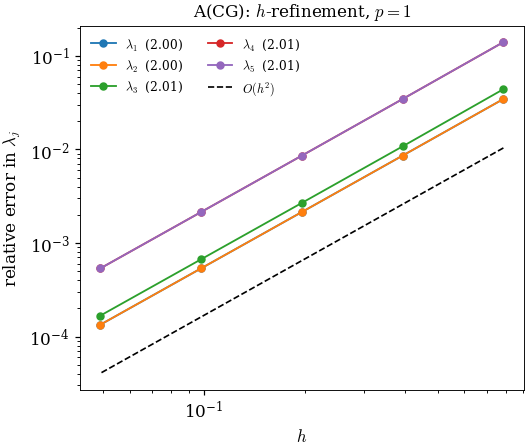

In [11]:
df = h_eig[("A(CG)", 1)]
h = df["h"].to_numpy()
e1 = df[r"$\lambda_{1}$"].to_numpy()
e2 = df[r"$\lambda_{2}$"].to_numpy()
e3 = df[r"$\lambda_{3}$"].to_numpy()
e4 = df[r"$\lambda_{4}$"].to_numpy()
e5 = df[r"$\lambda_{5}$"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color="C0", ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color="C1", ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color="C2", ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color="C3", ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color="C4", ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^{2})$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"A(CG): $h$-refinement, $p = 1$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "baseline_h_p1_ACG.pdf")
plt.show()

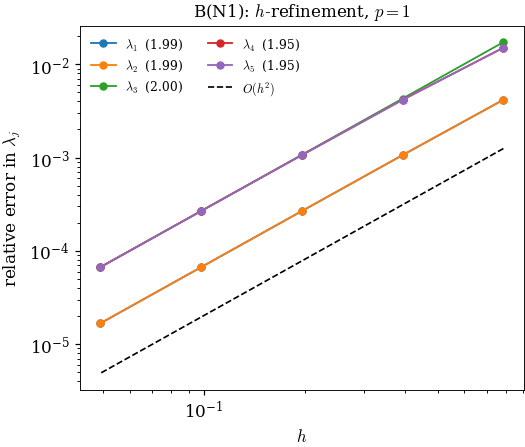

In [12]:
df = h_eig[("B(N1)", 1)]
h = df["h"].to_numpy()
e1 = df[r"$\lambda_{1}$"].to_numpy()
e2 = df[r"$\lambda_{2}$"].to_numpy()
e3 = df[r"$\lambda_{3}$"].to_numpy()
e4 = df[r"$\lambda_{4}$"].to_numpy()
e5 = df[r"$\lambda_{5}$"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color="C0", ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color="C1", ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color="C2", ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color="C3", ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color="C4", ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^{2})$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"B(N1): $h$-refinement, $p = 1$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "baseline_h_p1_BN1.pdf")
plt.show()

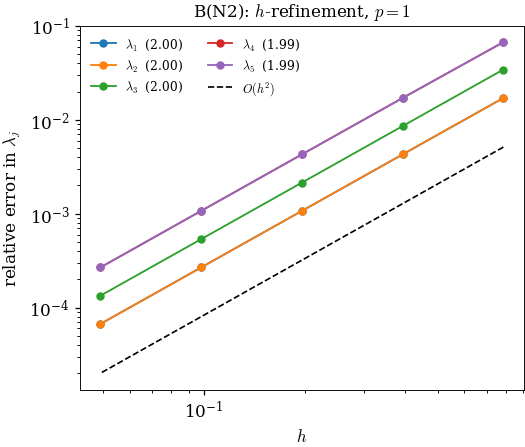

In [13]:
df = h_eig[("B(N2)", 1)]
h = df["h"].to_numpy()
e1 = df[r"$\lambda_{1}$"].to_numpy()
e2 = df[r"$\lambda_{2}$"].to_numpy()
e3 = df[r"$\lambda_{3}$"].to_numpy()
e4 = df[r"$\lambda_{4}$"].to_numpy()
e5 = df[r"$\lambda_{5}$"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color="C0", ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color="C1", ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color="C2", ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color="C3", ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color="C4", ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^{2})$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"B(N2): $h$-refinement, $p = 1$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "baseline_h_p1_BN2.pdf")
plt.show()

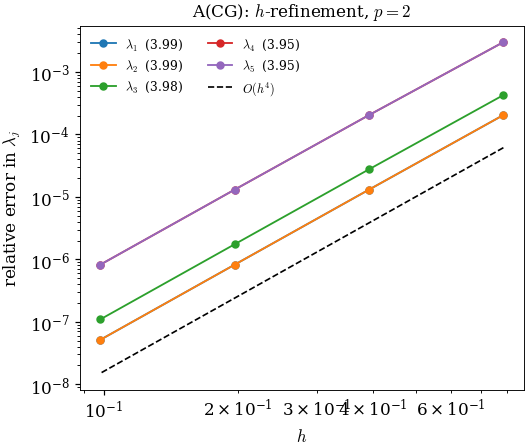

In [14]:
df = h_eig[("A(CG)", 2)]
h = df["h"].to_numpy()
e1 = df[r"$\lambda_{1}$"].to_numpy()
e2 = df[r"$\lambda_{2}$"].to_numpy()
e3 = df[r"$\lambda_{3}$"].to_numpy()
e4 = df[r"$\lambda_{4}$"].to_numpy()
e5 = df[r"$\lambda_{5}$"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color="C0", ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color="C1", ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color="C2", ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color="C3", ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color="C4", ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 4, "k--", lw=1.1, label=r"$O(h^{4})$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"A(CG): $h$-refinement, $p = 2$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "baseline_h_p2_ACG.pdf")
plt.show()

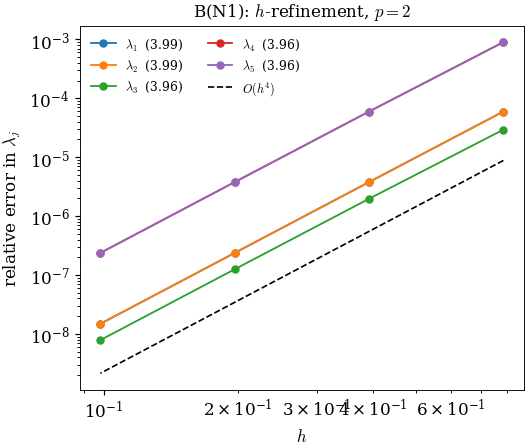

In [15]:
df = h_eig[("B(N1)", 2)]
h = df["h"].to_numpy()
e1 = df[r"$\lambda_{1}$"].to_numpy()
e2 = df[r"$\lambda_{2}$"].to_numpy()
e3 = df[r"$\lambda_{3}$"].to_numpy()
e4 = df[r"$\lambda_{4}$"].to_numpy()
e5 = df[r"$\lambda_{5}$"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color="C0", ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color="C1", ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color="C2", ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color="C3", ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color="C4", ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 4, "k--", lw=1.1, label=r"$O(h^{4})$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"B(N1): $h$-refinement, $p = 2$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "baseline_h_p2_BN1.pdf")
plt.show()

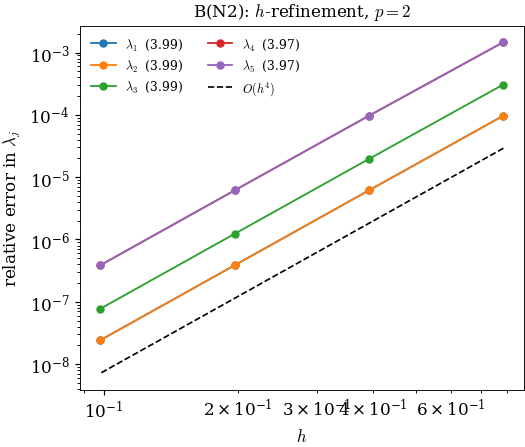

In [16]:
df = h_eig[("B(N2)", 2)]
h = df["h"].to_numpy()
e1 = df[r"$\lambda_{1}$"].to_numpy()
e2 = df[r"$\lambda_{2}$"].to_numpy()
e3 = df[r"$\lambda_{3}$"].to_numpy()
e4 = df[r"$\lambda_{4}$"].to_numpy()
e5 = df[r"$\lambda_{5}$"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color="C0", ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color="C1", ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color="C2", ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color="C3", ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color="C4", ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 4, "k--", lw=1.1, label=r"$O(h^{4})$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"B(N2): $h$-refinement, $p = 2$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "baseline_h_p2_BN2.pdf")
plt.show()

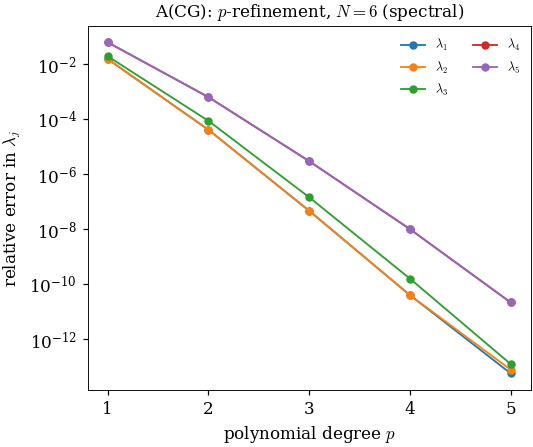

In [17]:
df = p_tables["A(CG)"]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[r"$\lambda_{1}$"], "o-", color="C0", ms=4.5, lw=1.2, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[r"$\lambda_{2}$"], "o-", color="C1", ms=4.5, lw=1.2, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[r"$\lambda_{3}$"], "o-", color="C2", ms=4.5, lw=1.2, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[r"$\lambda_{4}$"], "o-", color="C3", ms=4.5, lw=1.2, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[r"$\lambda_{5}$"], "o-", color="C4", ms=4.5, lw=1.2, label=r"$\lambda_{5}$")
ax.set_xlabel(r"polynomial degree $p$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"A(CG): $p$-refinement, $N = {}$ (spectral)".format(N_PREF))
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "baseline_pref_ACG.pdf")
plt.show()

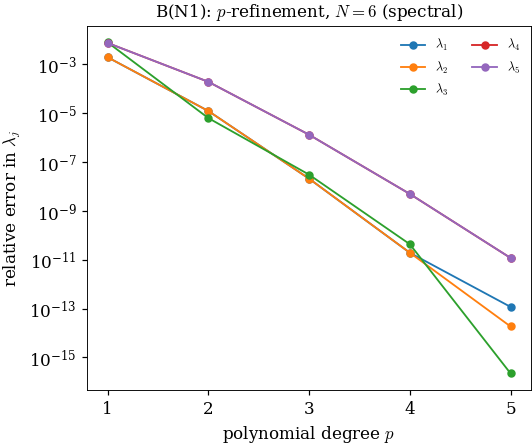

In [18]:
df = p_tables["B(N1)"]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[r"$\lambda_{1}$"], "o-", color="C0", ms=4.5, lw=1.2, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[r"$\lambda_{2}$"], "o-", color="C1", ms=4.5, lw=1.2, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[r"$\lambda_{3}$"], "o-", color="C2", ms=4.5, lw=1.2, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[r"$\lambda_{4}$"], "o-", color="C3", ms=4.5, lw=1.2, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[r"$\lambda_{5}$"], "o-", color="C4", ms=4.5, lw=1.2, label=r"$\lambda_{5}$")
ax.set_xlabel(r"polynomial degree $p$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"B(N1): $p$-refinement, $N = {}$ (spectral)".format(N_PREF))
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "baseline_pref_BN1.pdf")
plt.show()

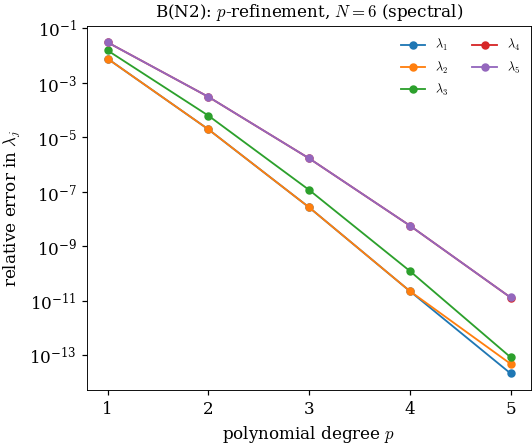

In [19]:
df = p_tables["B(N2)"]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[r"$\lambda_{1}$"], "o-", color="C0", ms=4.5, lw=1.2, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[r"$\lambda_{2}$"], "o-", color="C1", ms=4.5, lw=1.2, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[r"$\lambda_{3}$"], "o-", color="C2", ms=4.5, lw=1.2, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[r"$\lambda_{4}$"], "o-", color="C3", ms=4.5, lw=1.2, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[r"$\lambda_{5}$"], "o-", color="C4", ms=4.5, lw=1.2, label=r"$\lambda_{5}$")
ax.set_xlabel(r"polynomial degree $p$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"B(N2): $p$-refinement, $N = {}$ (spectral)".format(N_PREF))
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "baseline_pref_BN2.pdf")
plt.show()

**Identical rates are observed for all three formulations** — $O(h^{2p})$ under
$h$-refinement at both $p=1$ and $p=2$, for every one of the five eigenvalues, and
exponential convergence under $p$-refinement. Any one of these panels can therefore carry
the main text and the other two belong in an appendix.

The eigenfunction panels below are the counterpart of the $h$-refinement ones, and are the
one place where the three formulations genuinely differ.

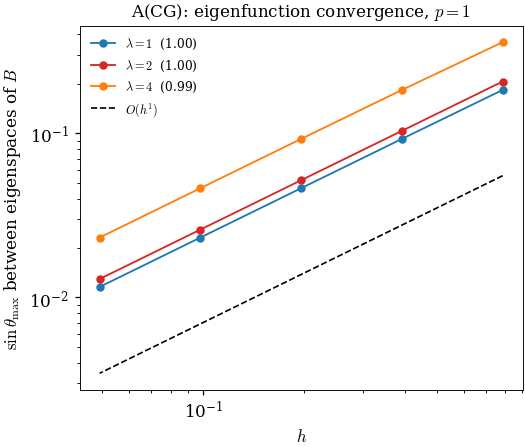

In [20]:
df = h_fun["A(CG)"]
h = df["h"].to_numpy()
g1 = df[r"$\lambda=1$"].to_numpy()
g2 = df[r"$\lambda=2$"].to_numpy()
g3 = df[r"$\lambda=4$"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, g1, "o-", color="C0", ms=4.5, lw=1.2,
          label=rf"$\lambda = 1$  ({np.nanmean(rates(h, g1)[1:]):.2f})")
ax.loglog(h, g2, "o-", color="C3", ms=4.5, lw=1.2,
          label=rf"$\lambda = 2$  ({np.nanmean(rates(h, g2)[1:]):.2f})")
ax.loglog(h, g3, "o-", color="C1", ms=4.5, lw=1.2,
          label=rf"$\lambda = 4$  ({np.nanmean(rates(h, g3)[1:]):.2f})")

ref = 0.30 * min(g1[0], g2[0], g3[0])
ax.loglog(h, ref * (h / h[0]) ** 1, "k--", lw=1.1, label=r"$O(h^{1})$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\sin\theta_{\max}$ between eigenspaces of $B$")
ax.set_title(r"A(CG): eigenfunction convergence, $p = 1$")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "baseline_eigfun_ACG.pdf")
plt.show()

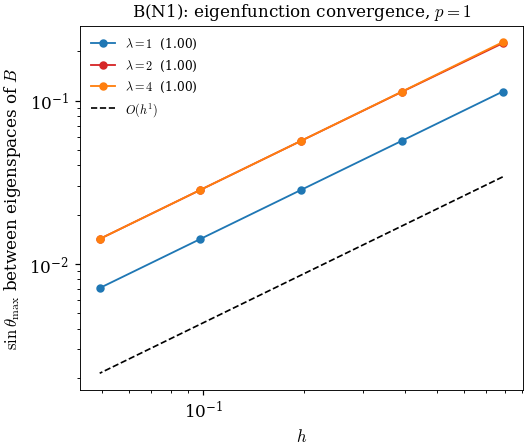

In [21]:
df = h_fun["B(N1)"]
h = df["h"].to_numpy()
g1 = df[r"$\lambda=1$"].to_numpy()
g2 = df[r"$\lambda=2$"].to_numpy()
g3 = df[r"$\lambda=4$"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, g1, "o-", color="C0", ms=4.5, lw=1.2,
          label=rf"$\lambda = 1$  ({np.nanmean(rates(h, g1)[1:]):.2f})")
ax.loglog(h, g2, "o-", color="C3", ms=4.5, lw=1.2,
          label=rf"$\lambda = 2$  ({np.nanmean(rates(h, g2)[1:]):.2f})")
ax.loglog(h, g3, "o-", color="C1", ms=4.5, lw=1.2,
          label=rf"$\lambda = 4$  ({np.nanmean(rates(h, g3)[1:]):.2f})")

ref = 0.30 * min(g1[0], g2[0], g3[0])
ax.loglog(h, ref * (h / h[0]) ** 1, "k--", lw=1.1, label=r"$O(h^{1})$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\sin\theta_{\max}$ between eigenspaces of $B$")
ax.set_title(r"B(N1): eigenfunction convergence, $p = 1$")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "baseline_eigfun_BN1.pdf")
plt.show()

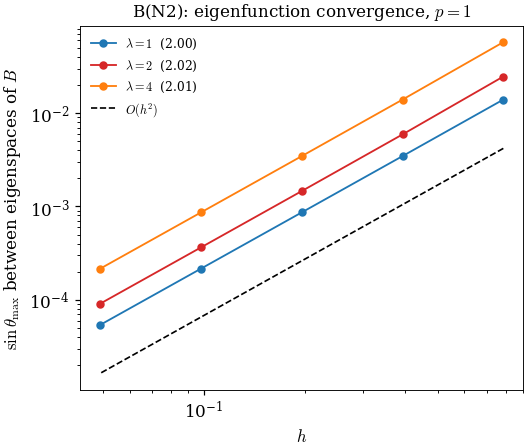

In [22]:
df = h_fun["B(N2)"]
h = df["h"].to_numpy()
g1 = df[r"$\lambda=1$"].to_numpy()
g2 = df[r"$\lambda=2$"].to_numpy()
g3 = df[r"$\lambda=4$"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, g1, "o-", color="C0", ms=4.5, lw=1.2,
          label=rf"$\lambda = 1$  ({np.nanmean(rates(h, g1)[1:]):.2f})")
ax.loglog(h, g2, "o-", color="C3", ms=4.5, lw=1.2,
          label=rf"$\lambda = 2$  ({np.nanmean(rates(h, g2)[1:]):.2f})")
ax.loglog(h, g3, "o-", color="C1", ms=4.5, lw=1.2,
          label=rf"$\lambda = 4$  ({np.nanmean(rates(h, g3)[1:]):.2f})")

ref = 0.30 * min(g1[0], g2[0], g3[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^{2})$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\sin\theta_{\max}$ between eigenspaces of $B$")
ax.set_title(r"B(N2): eigenfunction convergence, $p = 1$")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "baseline_eigfun_BN2.pdf")
plt.show()

<a id="5"></a>
## 5. Pseudospectra for $W^{1,\infty}$ winds

### 5.1 What is computed

For the pencil $(A, M)$ the $\varepsilon$-pseudospectrum is taken in the van
Dorsselaer/Frayssé sense for generalised problems,

$$
\sigma_\varepsilon(A,M) \;=\; \bigl\{\, z\in\mathbb{C} : \|(zM-A)^{-1}\|_2 \ge \varepsilon^{-1} \,\bigr\}
\;=\; \bigl\{\, z\in\mathbb{C} : \sigma_{\min}(zM-A) \le \varepsilon \,\bigr\},
$$

so plotting the level sets of $z\mapsto\sigma_{\min}(zM-A)$ draws every
$\varepsilon$-pseudospectrum at once. For a **normal** operator those level sets are exact
discs of radius $\varepsilon$ about the eigenvalues; how far they bulge beyond such discs
measures the non-normality.

The method is the **partial Schur projection** developed in
`Lshape_Pseudospectra_Partial_Schur.ipynb`. It now lives in
`pseudospectra_partial_schur.py`, imported at the top of this notebook as `ps`: the module
takes assembled `PETSc.Mat` objects and knows nothing about the formulation that produced
them, so the same code serves this study and the top-form benchmark. The six steps it runs
are:

| Step | Object | Tool |
|---|---|---|
| 1 | saddle-point pencil $(A,M)$, $M$ singular | Firedrake |
| 2 | reciprocal shift-and-invert about $\tau$ | SLEPc `EPS` + `ST` |
| 3 | orthonormal basis $Q$ of the invariant subspace; $A_m = Q^*AQ$, $M_m = Q^*MQ$ | column-pivoted QR |
| 4 | generalised Schur $A_m = W S V^*$, $M_m = W T V^*$ | `scipy.linalg.qz` |
| 5 | $\mathcal{R}(z) = \sigma_{\min}(S - zT)$ at random $z$ | `scipy.linalg.svdvals` |
| 6 | scatter $\to$ grid, contour by decade | `griddata` |

Since $W, V$ are unitary, $\sigma_{\min}(S-zT) = \sigma_{\min}(A_m - zM_m)$ exactly; the QZ
is done once and each sample costs one small triangular SVD.

### 5.2 The two winds

Both fields are taken **literally as tabulated** (Table 4.1), i.e. about the origin rather
than the domain centre, and both are $W^{1,\infty}$ — smooth, Lipschitz, the easy case.
They differ in exactly one structural property.

| Tag | $\beta$ | $\nabla\!\cdot\beta$ | $\beta = \nabla\phi$ | consequence |
|:--|:--|:--:|:--:|:--|
| `b2` | $(x,\,-y)$ | $0$ | **yes**, $\phi = \tfrac12(x^2-y^2)$ | King's Theorem 7 $\Rightarrow$ spectrum **real** |
| `b4` | $(-y,\,x)$ | $0$ | no | spectrum leaves the real axis |

For a potential field the operator is conjugate to a self-adjoint one — writing
$A = e^{\phi/2\varepsilon}w$ turns $-\varepsilon\Delta A + \nabla\phi\cdot\nabla A$ into the
real Schrödinger operator $-\varepsilon\Delta w + \bigl(\tfrac{|\nabla\phi|^2}{4\varepsilon} - \tfrac{\Delta\phi}{2}\bigr)w$
— so `b2` must give a real spectrum and near-circular level sets. `b4` has no such
structure. Putting them side by side is what makes the pseudospectrum panels readable.

In [23]:
def wind_b2(mesh):
    """beta_2 = (x, -y): linear, solenoidal, and a gradient field."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([x, -y])


def wind_b4(mesh):
    """beta_4 = (-y, x): rigid rotation about the origin; solenoidal, not a gradient."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([-y, x])


PS_WINDS = {"b2": (r"$\beta_2=(x,\,-y)$", wind_b2, "gradient field"),
            "b4": (r"$\beta_4=(-y,\,x)$", wind_b4, "rigid rotation")}

RM_PS = 1.0       # see Section 6: R_m is swept later, and not here
N_PS = 24
TAU_PS = 0.9 / RM_PS
NEV_PS = 50

# Cell Peclet number: with ||beta||_inf = pi*sqrt(2) on this domain the
# unstabilised Galerkin discretisation needs h ||beta|| Rm / 2 <~ 1.
beta_sup = np.pi * np.sqrt(2)
print(f"cell Peclet = {(np.pi / N_PS) * beta_sup * RM_PS / 2:.3f}   "
      f"(must stay <~ 1; no stabilisation is used anywhere)")

cell Peclet = 0.291   (must stay <~ 1; no stabilisation is used anywhere)


Each figure below is drawn in its own cell and saved to its own file, one panel per
figure, so that they can be arranged freely in a document rather than being locked into a
grid chosen here.

The two fields, side by side only in the sense that they follow one another:

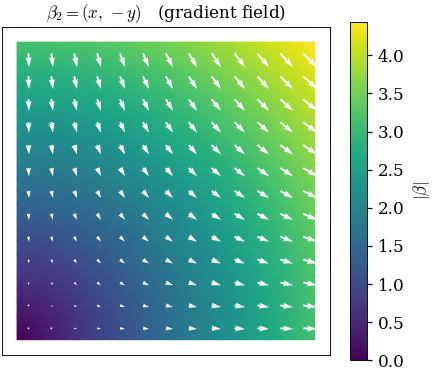

In [24]:
mesh_w = crisscross_mesh(12)
beta_w = wind_b2(mesh_w)
field_w = Function(VectorFunctionSpace(mesh_w, "CG", 1)).interpolate(beta_w)
speed_w = Function(FunctionSpace(mesh_w, "CG", 1)).interpolate(sqrt(dot(beta_w, beta_w)))

# Arrow positions on a regular grid.  PointEvaluator is the supported replacement
# for the deprecated Function.at; the tight tolerance stops points being snapped
# into neighbouring cells.
grid_w = np.linspace(0.12, np.pi - 0.12, 13)
Xw, Yw = np.meshgrid(grid_w, grid_w)
vals_w = np.asarray(PointEvaluator(mesh_w, np.column_stack([Xw.ravel(), Yw.ravel()]),
                                   missing_points_behaviour="ignore",
                                   tolerance=1e-6).evaluate(field_w))
Uw = vals_w[:, 0].reshape(Xw.shape)
Vw = vals_w[:, 1].reshape(Xw.shape)
step_w = float(grid_w[1] - grid_w[0])

fig, ax = plt.subplots(figsize=(4.8, 4.0))
art = tripcolor(speed_w, axes=ax, cmap="viridis")
ax.quiver(Xw, Yw, Uw, Vw, color="w", angles="xy", scale_units="xy",
          scale=np.hypot(Uw, Vw).max() / (0.85 * step_w), width=0.006)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"$\beta_2 = (x,\,-y)$   (gradient field)")
fig.colorbar(art, ax=ax, label=r"$|\beta|$")
fig.savefig(FIGDIR / "baseline_wind_b2.pdf")
plt.show()

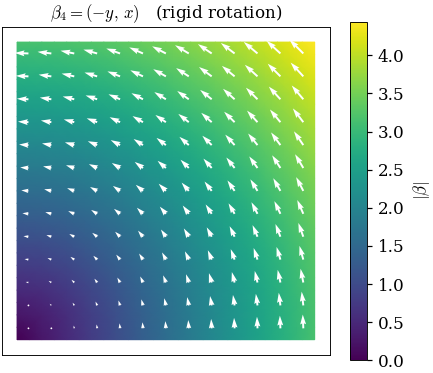

In [25]:
mesh_w = crisscross_mesh(12)
beta_w = wind_b4(mesh_w)
field_w = Function(VectorFunctionSpace(mesh_w, "CG", 1)).interpolate(beta_w)
speed_w = Function(FunctionSpace(mesh_w, "CG", 1)).interpolate(sqrt(dot(beta_w, beta_w)))

# Arrow positions on a regular grid.  PointEvaluator is the supported replacement
# for the deprecated Function.at; the tight tolerance stops points being snapped
# into neighbouring cells.
grid_w = np.linspace(0.12, np.pi - 0.12, 13)
Xw, Yw = np.meshgrid(grid_w, grid_w)
vals_w = np.asarray(PointEvaluator(mesh_w, np.column_stack([Xw.ravel(), Yw.ravel()]),
                                   missing_points_behaviour="ignore",
                                   tolerance=1e-6).evaluate(field_w))
Uw = vals_w[:, 0].reshape(Xw.shape)
Vw = vals_w[:, 1].reshape(Xw.shape)
step_w = float(grid_w[1] - grid_w[0])

fig, ax = plt.subplots(figsize=(4.8, 4.0))
art = tripcolor(speed_w, axes=ax, cmap="viridis")
ax.quiver(Xw, Yw, Uw, Vw, color="w", angles="xy", scale_units="xy",
          scale=np.hypot(Uw, Vw).max() / (0.85 * step_w), width=0.006)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"$\beta_4 = (-y,\,x)$   (rigid rotation)")
fig.colorbar(art, ax=ax, label=r"$|\beta|$")
fig.savefig(FIGDIR / "baseline_wind_b4.pdf")
plt.show()

### 5.3 Running it

Everything above is one call. The notebook's only job is to assemble the pencil for a given
(formulation, wind) pair and hand it over; `ps.pseudospectrum` returns a dict carrying the
field to plot, the Ritz values, and the diagnostics needed to decide whether to believe it.

In [26]:
def run_pseudospectrum(form, mesh, wind_key, Rm=RM_PS, tau=TAU_PS, nev=NEV_PS,
                       p=1, **kw):
    """Assemble the pencil for one configuration and project it."""
    label, wind_fn, note = PS_WINDS[wind_key]
    A, M, _ = build_pencil(form, mesh, p, beta=wind_fn(mesh), eps=Constant(1.0 / Rm))
    # Everything after this point is formulation-agnostic and lives in the module.
    return ps.pseudospectrum(A, M, tau, nev=nev, label=label,
                             form=form, wind=wind_key, Rm=Rm, **kw)


mesh_ps = crisscross_mesh(N_PS)
results = {(f, w): run_pseudospectrum(f, mesh_ps, w) for w in PS_WINDS for f in FORMS}

fmt_table(ps.diagnostics_frame(results), default="{:.3e}",
          rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}"),
                 ("max |Im| in window", "{:.2e}"), ("max |Im| all ritz", "{:.2e}")],
          caption=r"Projection diagnostics. `QZ residual` checks the unitary "
                  r"factorisation; `window fidelity` is $\max|\lambda_{\rm SLEPc} - "
                  r"\mathrm{Ritz}|$ over the eigenvalues actually plotted.")

**Projection diagnostics. `QZ residual` checks the unitary factorisation; `window fidelity` is $\max|\lambda_{\rm SLEPc} - \mathrm{Ritz}|$ over the eigenvalues actually plotted.**

,,N,m,QZ residual,max |Im| in window,max |Im| all ritz,window fidelity,eigs in window
form,wind,,,,,,,
A(CG),b2,1202,53,1.686e-15,4.09e-15,3.54e-03,1.067e-13,10
B(N1),b2,4705,53,6.040e-13,1.05e-15,5.21e-15,1.581e-13,10
B(N2),b2,11713,53,5.400e-13,2.44e-28,1.25e-24,4.885e-13,10
A(CG),b4,1202,55,7.439e-15,2.49e+00,6.89e+00,7.219e-14,11
B(N1),b4,4705,55,7.888e-13,2.47e+00,6.75e+00,1.228e-13,11
B(N2),b4,11713,55,5.477e-13,2.49e+00,6.97e+00,1.930e-13,11


The QZ residuals are at machine precision and the window fidelity at $10^{-13}$, so the
compression is exact for everything drawn.

The two imaginary-part columns are the King's-theorem check, and the distinction between
them matters. **Inside the plotted window the `b2` spectrum is real to round-off** in all
three formulations, which is what Theorem 7 requires of a gradient field. Over *all* Ritz
values the maximum is larger — around $10^{-3}$ for `A(CG)` — but that comes from the
outermost few, which a one-sided projection reproduces worst and which lie outside the
picture. For `b4` both columns are $O(1)$: those imaginary parts are the physics.

Six panels, one per (wind, formulation) pair, each in its own cell and its own file.
`ps.plot_pseudospectrum` draws the field, the decade contours and the eigenvalues; the
window is chosen automatically around the Ritz values nearest the target.

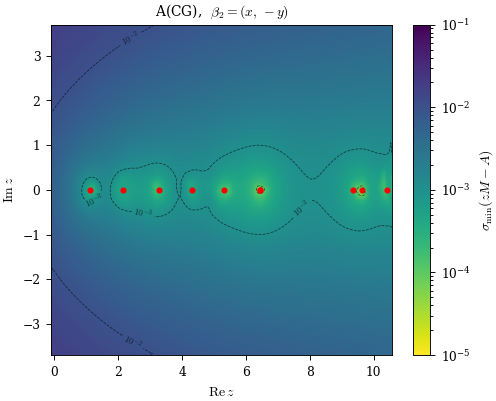

In [27]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.0, 3.9))
    ps.plot_pseudospectrum(results[("A(CG)", "b2")], ax=ax,
                           title=r"A(CG),  " + PS_WINDS["b2"][0])
    fig.savefig(FIGDIR / "baseline_pseudo_b2_ACG.pdf")
    plt.show()

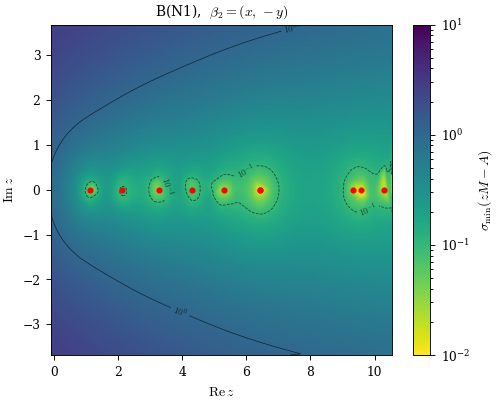

In [28]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.0, 3.9))
    ps.plot_pseudospectrum(results[("B(N1)", "b2")], ax=ax,
                           title=r"B(N1),  " + PS_WINDS["b2"][0])
    fig.savefig(FIGDIR / "baseline_pseudo_b2_BN1.pdf")
    plt.show()

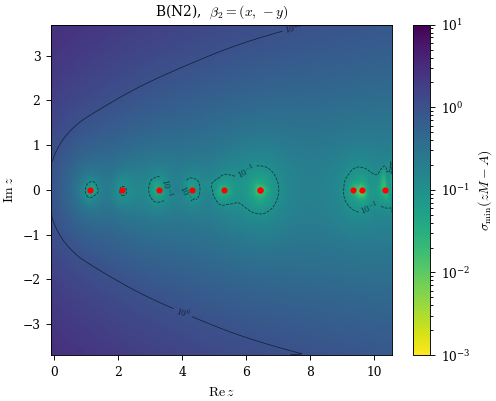

In [29]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.0, 3.9))
    ps.plot_pseudospectrum(results[("B(N2)", "b2")], ax=ax,
                           title=r"B(N2),  " + PS_WINDS["b2"][0])
    fig.savefig(FIGDIR / "baseline_pseudo_b2_BN2.pdf")
    plt.show()

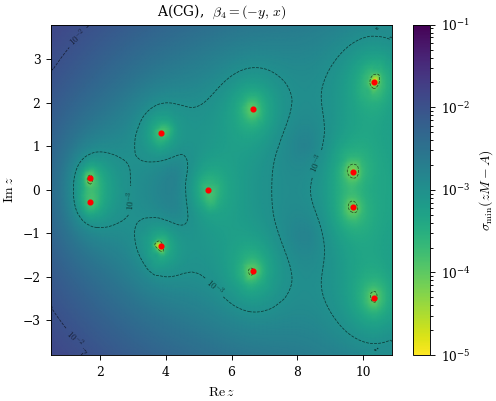

In [30]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.0, 3.9))
    ps.plot_pseudospectrum(results[("A(CG)", "b4")], ax=ax,
                           title=r"A(CG),  " + PS_WINDS["b4"][0])
    fig.savefig(FIGDIR / "baseline_pseudo_b4_ACG.pdf")
    plt.show()

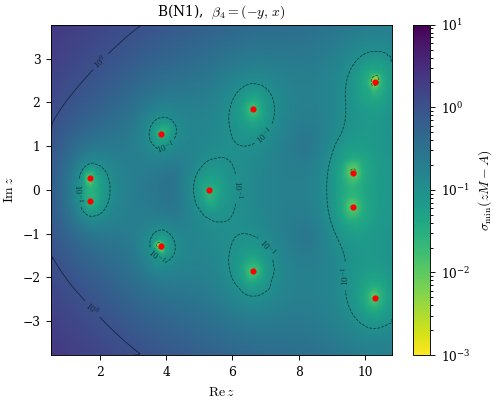

In [31]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.0, 3.9))
    ps.plot_pseudospectrum(results[("B(N1)", "b4")], ax=ax,
                           title=r"B(N1),  " + PS_WINDS["b4"][0])
    fig.savefig(FIGDIR / "baseline_pseudo_b4_BN1.pdf")
    plt.show()

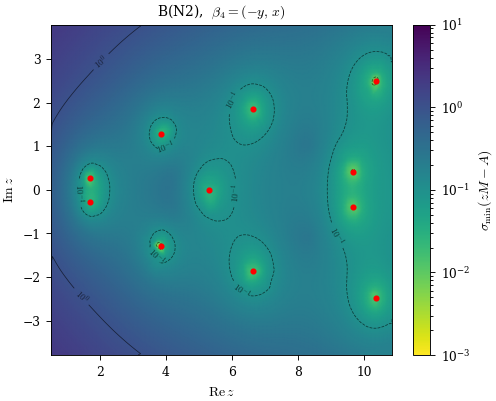

In [32]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.0, 3.9))
    ps.plot_pseudospectrum(results[("B(N2)", "b4")], ax=ax,
                           title=r"B(N2),  " + PS_WINDS["b4"][0])
    fig.savefig(FIGDIR / "baseline_pseudo_b4_BN2.pdf")
    plt.show()

### 5.4 Reading the panels

**The spectrum and the pseudospectrum agree, which is the point of the exercise.** For
both $W^{1,\infty}$ fields the level sets close tightly around the red eigenvalues and
remain close to circular: a $z$ far from every eigenvalue has a correspondingly small
resolvent, so the eigenvalues predict the behaviour of the operator and nothing is hiding
between them. This is the well-behaved regime, and it is the control against which the
later low-regularity experiments must be read.

Two differences between the rows are worth naming.

* **`b2` (top row).** The spectrum is real to round-off and the contours are very nearly
  discs, which is what conjugation to a self-adjoint operator demands. The operator is
  advected but, in the relevant sense, still normal.
* **`b4` (bottom row).** The rotation moves the eigenvalues into conjugate pairs spread
  through the complex plane, and each pair still carries its own tight, near-circular
  well. A little non-normality has appeared, but only a little.

One feature is an artefact rather than a result: in every panel the contours merge into
broad lobes at the **right-hand edge** of the window. That is where the Ritz values are
least converged and where a one-sided projection is loosest, not where the operator is
most non-normal. Read the interior of each window, not its edge — and if a feature there
matters, enlarge `nev` until it stops moving.

Across the columns the *shapes* agree; the absolute $\sigma_{\min}$ **levels** do not, and
should not be compared. $Q$ is orthonormal in the Euclidean inner product, which is the
literal matrix-pencil definition, so $\sigma_{\min}$ inherits the $O(h^d)$ scaling of the
mass matrix and the `A(CG)` panels sit decades below the `B` panels for that reason alone.
Compare shapes between formulations, levels only within one.

<a id="6"></a>
## 6. What is deliberately not here

This section is the **baseline**: a convex domain, an analytic spectrum, and winds that are
Lipschitz. Everything in it is meant to be uninteresting, so that departures later can be
attributed rather than guessed at.

Two variables are therefore held fixed and explored elsewhere.

* **The magnetic Reynolds number.** Every pseudospectrum above is computed at $R_m = 1$.
  Raising $R_m$ weakens diffusion relative to advection and drives the operator away from
  normality; that sweep belongs with the fields for which it produces something, and is
  taken up in the following sections.
* **Low-regularity velocity fields.** $\beta_2$ and $\beta_4$ are $W^{1,\infty}$, the
  hypothesis under which the standard theory is comfortable. The fields that test the
  theory are the ones in $L^\infty\setminus W^{1,\infty}$ — the Heaviside shears
  $\beta_6, \beta_7, \beta_8$ — and those in $L^p$ only, such as the vortex $\beta_9$.
  **The interaction of $R_m$ with those fields is the subject of the following sections
  and is omitted here.**

There is also a constraint that applies throughout and is worth restating: nothing is
stabilised, deliberately, because SUPG and its relatives perturb the operator whose
spectrum is the object of study. Unstabilised Galerkin advection–diffusion is dependable
only while the cell Péclet number $h\|\beta\|_\infty R_m/2 \lesssim 1$, which on
$(0,\pi)^2$ with $\|\beta\|_\infty = \pi\sqrt2$ means $N \gtrsim \pi^2\sqrt2\,R_m/2$. The
value printed in Section 5.2 confirms the bound is respected here.

In [33]:
klog = pd.DataFrame(KAPPA_LOG)
worst = klog.loc[klog[r"Hager $\kappa_1$"].idxmax()]
print(f"{len(klog)} eigensolves, each with kappa(A - tau M) estimated.\n")
print(f"  worst normwise kappa_1 : {worst[r'Hager $\kappa_1$']:.3e}"
      f"   ({worst['form']}, p={worst['p']:.0f}, {worst['N']:.0f} cells)")
print(f"  median normwise kappa_1: {klog[r'Hager $\kappa_1$'].median():.3e}")
print(f"  worst MUMPS COND1      : {klog['MUMPS COND1'].max():.3e}")
print(f"  MUMPS INFOG(1) != 0    : {int((klog['INFOG(1)'] != 0).sum())} of {len(klog)}")
print(f"\nfigures written to {FIGDIR.resolve()}")
for q in sorted(FIGDIR.glob("baseline_*.pdf")):
    print("  ", q.name)

45 eigensolves, each with kappa(A - tau M) estimated.

  worst normwise kappa_1 : 4.490e+07   (B(N2), p=1, 16384 cells)
  median normwise kappa_1: 9.668e+04
  worst MUMPS COND1      : 4.562e+04
  MUMPS INFOG(1) != 0    : 0 of 45

figures written to /Users/lourenco/Desktop/Dissertation_Firedrake/Experiments/final/figures
   baseline_eigfun_ACG.pdf
   baseline_eigfun_BN1.pdf
   baseline_eigfun_BN2.pdf
   baseline_h_p1_ACG.pdf
   baseline_h_p1_BN1.pdf
   baseline_h_p1_BN2.pdf
   baseline_h_p2_ACG.pdf
   baseline_h_p2_BN1.pdf
   baseline_h_p2_BN2.pdf
   baseline_pref_ACG.pdf
   baseline_pref_BN1.pdf
   baseline_pref_BN2.pdf
   baseline_pseudo_b2_ACG.pdf
   baseline_pseudo_b2_BN1.pdf
   baseline_pseudo_b2_BN2.pdf
   baseline_pseudo_b4_ACG.pdf
   baseline_pseudo_b4_BN1.pdf
   baseline_pseudo_b4_BN2.pdf
   baseline_wind_b2.pdf
   baseline_wind_b4.pdf
